# Marketing A/B Test

This notebook analyzes a marketing A/B test where the majority of people will be exposed to ads (treatment group), and a small portion of people (control group) would instead see a Public Service Announcement (PSA) (or nothing) in the exact size and place the ad would normally be.

We go through SRM (Sample Ratio Mismatch) check, EDA (Exploratory Data Analysis), we calculate MDE (Minimum Detectable Effect) and do the hypothesis testing using **Two Proportion Z-Test**, then we calculate effect size and confidence intervals, do a regression robustness check, and finally we give practical business recommendations.

Libraries used: numpy, pandas, scipy, statsmodels, matplotlib, seaborn

**Author:** Samael González

# Business Problem and Hypothesis

**Context:** A marketing company wants to run a successful campaign, so they do an A/B test, that is a randomized experimentation process wherein two versions of a variable (web page, page element, banner, etc.) are shown to different segments of people at the same time to determine which version leaves the maximum impact and drive business metrics.

In this case the majority of people will be exposed to ads (treatment group), and a small portion of people (control group) would instead see a Public Service Announcement (PSA) (or nothing) in the exact size and place the ad would normally be.

**Business problems:** Analyze the groups, find if the ads were successful, how much the company can make from the ads, and if the difference between the groups is statistically significant.

**Statistical Hypotheses:**
- **H0 (null):** conversion rate is the same for both groups — p_treatment = p_control
- **H1 (alternative):** conversion rate differs between groups — p_treatment ≠ p_control

Tested at **α = 0.05**, two-sided, since we don't assume in advance which direction a real
difference would go.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import chisquare
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Data

For this project, data was taken from Kaggle: https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing, data consist of 7 columns:


*   **Index**: Row index
*   **user id**: User ID (unique)
*   **test group**: If "ad" the person saw the advertisement, if "psa" they only saw the public service announcement
*   **converted**: If a person bought the product then True, else is False
*   **total ads**: Amount of ads seen by person
*   **most ads day**: Day that the person saw the biggest amount of ads
*   **most ads hour**: Hour of day that the person saw the biggest amount of ads

A total of 588,101 rows make up the dataset, the treatment group consists of 96% of the total while the control group consists of only 4% of the total. We assume a baseline (control) conversion ≈ 1.78%.



In [2]:
df = pd.read_csv("marketing_AB.csv")
if 'Unnamed: 0' in df.columns:
  df = df.drop(columns=['Unnamed: 0'])
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [3]:
df['converted'] = df['converted'].astype(int)
summary = df.groupby('test group')['converted'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'n', 'sum': 'conversions', 'mean': 'conversion_rate'})
summary

,n,conversions,conversion_rate
test group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


# Sample Ratio Mismatch (SRM) Check

Before trusting any A/B test result, it's standard practice to check that the observed split between groups matches the *intended* randomization ratio. A mismatch (SRM) usually signals a bug in the assignment a logging pipeline, and it can silently invalidate an otherwise "significant" result.

This dataset's documentation states the design allocated ~96% of users to ad and ~4% to psa. We test the observed split against that target with a chi-square goodness-of-fit-test.

In [4]:
n_total = summary['n'].sum()
observed = [summary.loc['ad', 'n'], summary.loc['psa', 'n']]
expected_ratio = [0.96, 0.04]
expected = [r * n_total for r in expected_ratio]

chi2_srm, p_srm = chisquare(f_obs=observed, f_exp=expected)

print(f"Observed split: {observed[0]:,} / {observed[1]:,}")
print(f"Expected split ({expected_ratio[0]:.0%}/{expected_ratio[1]:.0%}): {expected[0]:,.0f} / {expected[1]:,.0f}")
print(f"Chi-square: {chi2_srm:.4f}, p-value: {p_srm:.4f}")
print("No evidence of sample ratio mismatch" if p_srm >= 0.01
      else "Possible sample ratio mismatch")

Observed split: 564,577 / 23,524
Expected split (96%/4%): 564,577 / 23,524
Chi-square: 0.0000, p-value: 0.9998
No evidence of sample ratio mismatch


# Exploratory Data Analysis (EDA)



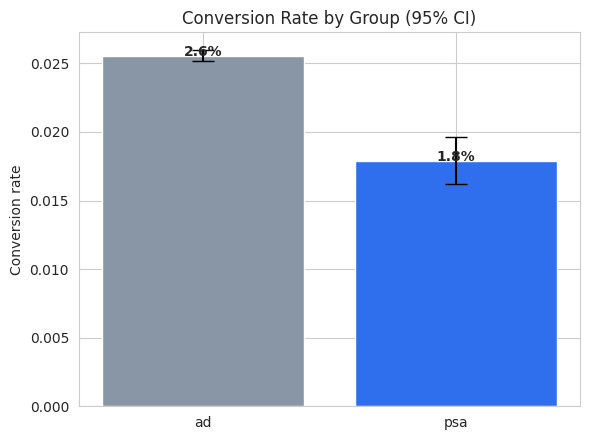

In [5]:
def wilson_ci(conversions, n, z=1.96):
  p = conversions / n
  denom = 1 + z**2 / n
  center = (p + z**2 / (2*n)) / denom
  margin = (z * np.sqrt((p*(1-p) + z**2/(4*n)) / n)) / denom
  return center - margin, center + margin

fig, ax = plt.subplots(figsize=(6, 4.5))
rates = summary['conversion_rate'].values
cis = [wilson_ci(summary.loc[g, 'conversions'], summary.loc[g, 'n']) for g in summary.index]
errors = [[rates[i] - ci[0] for i, ci in enumerate(cis)],
          [ci[1] - rates[i] for i, ci in enumerate(cis)]]

ax.bar(summary.index, rates, yerr=errors, capsize=8, color=['#8896a6', '#2f6fed'])
ax.set_ylabel('Conversion rate')
ax.set_title('Conversion Rate by Group (95% CI)')
for i, r in enumerate(rates):
  ax.text(i, r, f"{r:.1%}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Ad Exposure EDA

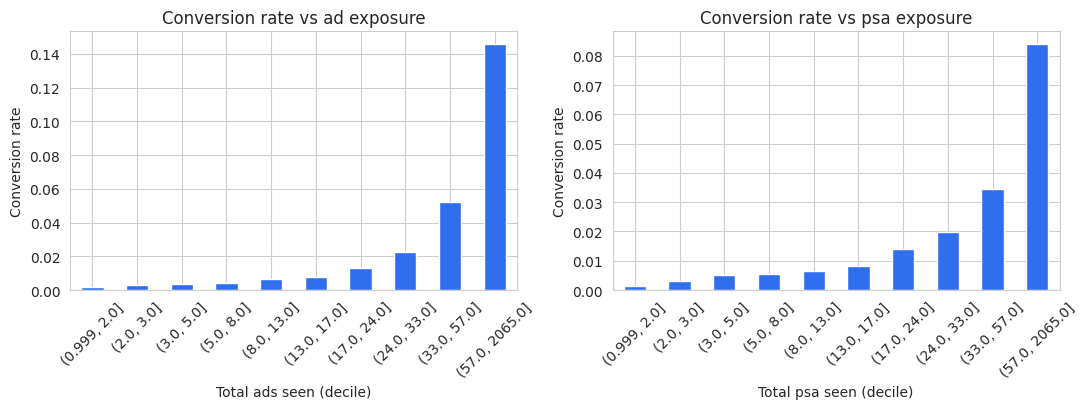

,n,conversion_rate
ads_bucket,,
"(0.999, 2.0]",92209,0.001920
"(2.0, 3.0]",27328,0.002818
"(3.0, 5.0]",50425,0.003431
"(5.0, 8.0]",56051,0.004210
"(8.0, 13.0]",60882,0.006833
"(13.0, 17.0]",56368,0.007788
"(17.0, 24.0]",61873,0.012946
"(24.0, 33.0]",47226,0.022742
"(33.0, 57.0]",57194,0.052401


In [6]:
df['ads_bucket'] = pd.qcut(df['total ads'], q=10, duplicates='drop')
dose_ad = df[df['test group'] == 'ad'].groupby('ads_bucket', observed=True)['converted'].agg(n='count', conversion_rate='mean')
dose_psa = df[df['test group'] == 'psa'].groupby('ads_bucket', observed=True)['converted'].agg(n='count', conversion_rate='mean')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

dose_ad['conversion_rate'].plot(kind='bar', ax = axes[0], color='#2f6fed')
axes[0].set_ylabel('Conversion rate')
axes[0].set_xlabel('Total ads seen (decile)')
axes[0].set_title('Conversion rate vs ad exposure')
axes[0].tick_params(axis='x', rotation=45)

dose_psa['conversion_rate'].plot(kind='bar', ax = axes[1], color='#2f6fed')
axes[1].set_ylabel('Conversion rate')
axes[1].set_xlabel('Total psa seen (decile)')
axes[1].set_title('Conversion rate vs psa exposure')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

dose_ad

**Caveat**: "total ads" is a consequence of treatment, so we exclude it from the analysis. It looks like "more ads -> more conversion" but in reality this is almost certainly driven by exposure duration or engagement confounding (people who stick around longer both see more ads and are more likely to eventually buy) rather than an ads effect.

Text(0.5, 1.0, 'Conversion rate by hour')

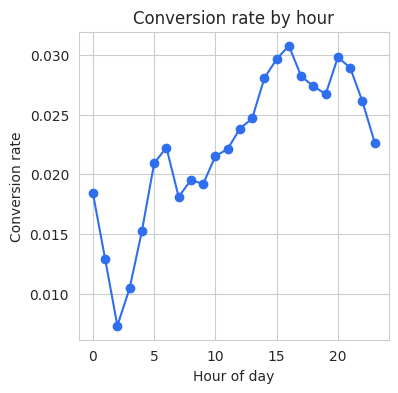

In [7]:
fig, ax = plt.subplots(figsize=(4, 4))

hourly = df.groupby('most ads hour', observed=True)['converted'].mean()
ax.plot(hourly.index, hourly.values, marker='o', color ='#2f6fed')
ax.set_ylabel('Conversion rate')
ax.set_xlabel('Hour of day')
ax.set_title('Conversion rate by hour')

# Minimum Detectable Effect (Sensitivity Check)

We calculate the **minimum detectable effect** (MDE): the smallest true lift this sample size could reliably detect, given **α = 0.05** and desired power **1-β=0.8**.

We use the following formula to calculate the MDE for different sized groups:

$$MDE \approx (z_{1-\alpha/2} + z_{1-\beta})\cdot\sqrt{p(1-p)\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}$$

In [8]:
def MDE (p, n_1, n_2, alpha=0.05, power=0.8):
  z_alpha = stats.norm.ppf(1 - alpha/2)
  z_beta = stats.norm.ppf(power)
  se = np.sqrt(p*(1 - p) * (1/n_1 + 1/n_2))
  r = (z_alpha + z_beta) * se
  return r

baseline_rate = summary.loc['psa', 'conversion_rate']
n_ad, n_psa = summary.loc['ad', 'n'], summary.loc['psa', 'n']

min_det_effect = MDE(baseline_rate, n_ad, n_psa)
diff = summary.loc['ad', 'conversion_rate'] - summary.loc['psa', 'conversion_rate']

print(f"Minimum Detectable Effect: {min_det_effect:.3f}")
print(f"Observed differences in conversion rate: {diff:.3f}")
print(f"Observed effect exceeds the MDE"
      if diff > min_det_effect else
      "Observed effect is below the MDE")

Minimum Detectable Effect: 0.002
Observed differences in conversion rate: 0.008
Observed effect exceeds the MDE


# Hypothesis Testing - Two Proportion Z-Test

We compare two independent proportions (conversion rate in each group) using the two proportion z-test. With large samples, the sampling distribution of a proportion is approximately normal (Central Limit Theorem), so a z-test is appropriate. We use the formula for the **Test statistic:**

$$z = \frac{p_1 - p_2}{\sqrt{\hat p(1-\hat p)\left(\frac{1}{n_1} + \frac{1}{n_2}\right)}}, \qquad \hat p = \frac{x_1 + x_2}{n_1 + n_2}$$

where $p_1$ is the conversion rate of the **ad** group, $p_2$ is the conversion rate of the **psa** group, and $\hat p$ is the **pooled** conversion rate across both groups.

We also cross-check against `statsmodels`' implementation to make sure the hand-rolled formula is right.

In [9]:
def two_proportion_ztest(x_1, n_1, x_2, n_2):
  p_1, p_2 = x_1 / n_1, x_2 / n_2
  p_pool = (x_1 + x_2) / (n_1 + n_2)
  se = np.sqrt(p_pool * (1-p_pool) * (1/n_1 + 1/n_2))
  z = (p_1 - p_2) / se
  p_value = 2 * stats.norm.sf(abs(z))
  return z, p_value

x_t, n_t = summary.loc['ad', 'conversions'], summary.loc['ad', 'n']
x_c, n_c = summary.loc['psa', 'conversions'], summary.loc['psa', 'n']

z_stat, p_value = two_proportion_ztest(x_t, n_t, x_c, n_c)

print(f"Control conversion: {x_c/n_c:.4f}")
print(f"Treatment conversion: {x_t/n_t:.4f}")
print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value:     {p_value:.3e}")
print(f"Significant at α=0.05? {'Yes' if p_value < 0.05 else 'No'}")

z_sm, p_sm = proportions_ztest(count=[x_t, x_c], nobs=[n_t, n_c])
print(f"\nstatsmodels cross-check: z={z_sm:.3f}, p={p_sm:.3e}   (matches: {np.isclose(z_stat, z_sm, atol=1e-6)})")

Control conversion: 0.0179
Treatment conversion: 0.0255
Z-statistic: 7.370
P-value:     1.705e-13
Significant at α=0.05? Yes

statsmodels cross-check: z=7.370, p=1.705e-13   (matches: True)


# Effect Size and Confidence Interval

We report:


1.   **Absolute difference** and its 95% confidence interval
2.   **Relative lift** (% improvement over baseline)
3.   **Cohen's h**: a standarized effect size for proportions, comparable across experiments regardless of baseline rate. Rough guide: 0.2 = small, 0.5 = medium, 0.8 = large.



In [10]:
p_t, p_c = x_t / n_t, x_c / n_c
se_diff = np.sqrt(p_t*(1-p_t)/n_t + p_c*(1-p_c)/n_c)
diff = p_t - p_c
ci_low, ci_high = diff - 1.96*se_diff, diff + 1.96*se_diff
rel_lift = diff / p_c * 100
cohens_h = 2*np.arcsin(np.sqrt(p_t)) - 2*np.arcsin(np.sqrt(p_c))

print(f"Absolute lift: {diff:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")
print(f"Relative lift: {rel_lift:.2f}%")
print(f"Cohen's h:     {cohens_h:.3f}")

Absolute lift: 0.0077 (95% CI: [0.0060, 0.0094])
Relative lift: 43.09%
Cohen's h:     0.053


# Regression Robustness Check

We use `LogisticRegression` as a robustness check: does the treatment effect hold up once we adjust for when someone was exposed (day/hour)?

We deliberately do not control for **total ads** here, because it is largely a consequence of being assigned to the **ad** group, it´s a post-treatment/mediator variable, not a pre-treatment confounder. Controlling for it would partly control away the very effect we're trying to measure and bias the treatment coefficient, **most ads day/most ads hour** are more like blocking variables (when someone happened to be online), so adjusting for those is safer.

In [24]:
X = pd.get_dummies(df[['test group', 'most ads day']], drop_first=True).astype(int)
X['most ads hour'] = df['most ads hour']
X_with_const = sm.add_constant(X)
y = df['converted']

logit_model = sm.Logit(y, X_with_const)
results = logit_model.fit()

report_psa = {'coefficient' : results.params['test group_psa'],
              'standard error' : results.bse['test group_psa'],
              'p_value' : results.pvalues['test group_psa'],
              'ci_high' : results.conf_int(alpha = 0.05)[0]['test group_psa'],
              'ci_low' : results.conf_int(alpha = 0.05)[1]['test group_psa']}

print(f"\nCoefficient on test group_psa (relative to 'ad' baseline): {report_psa['coefficient']:.4f}(95% CI: {report_psa['ci_low']:.4f}, {report_psa['ci_high']:.4f})")
print(f"With standard error: {report_psa['standard error']:.2f} and p-value: {report_psa['p_value']:.2f}")
print(f"Odds ratio (psa vs ad): {np.exp(report_psa['coefficient']):.4f}")

Optimization terminated successfully.
         Current function value: 0.117188
         Iterations 8

Coefficient on test group_psa (relative to 'ad' baseline): -0.3591(95% CI: -0.2611, -0.4570)
With standard error: 0.05 and p-value: 0.00
Odds ratio (psa vs ad): 0.6983


# Practical Significance

A "small" effect size doesn't mean "not worth", it depends on volume, suppose we have 100,000 monthly visitors.

We consider the cost of the ads necessary for the campaign to break even.

In [25]:
monthly_visitors = 100_000 # assumed trafic
product_price = 45        # USD, assumed
avg_ads_per_treated_user = df[df['test group'] == 'ad']['total ads'].mean()

incremental_sales = diff * monthly_visitors
incremental_revenue = incremental_sales * product_price
monthly_ads = avg_ads_per_treated_user * monthly_visitors
break_even_CPM = incremental_revenue / monthly_ads * 1000

print(f"Estimated incremental sales/month: {incremental_sales:,.0f}")
print(f"Estimated incremental revenue/month: ${incremental_revenue:,.0f}")
print(f"Estimated incremental revenue/year:  ${incremental_revenue*12:,.0f}")
print(f"\nAverage ads per treated user: {avg_ads_per_treated_user:,.2f}")
print(f"Monthly treated ads: {monthly_ads:,.0f}")
print(f"The campaign breaks even at a CPM of: ${break_even_CPM:.2f}")

Estimated incremental sales/month: 769
Estimated incremental revenue/month: $34,616
Estimated incremental revenue/year:  $415,392

Average ads per treated user: 24.82
Monthly treated ads: 2,482,337
The campaign breaks even at a CPM of: $13.94


# Business Recommendation

**Result:** Ads show a statistically significant conversion lift (control 1.78% -> treatment 2.55%, p < 0.001), a **~43% relative improvement** (.77 percentage points, 95% CI: [.6, .94] points), translating to an estimated **~$415k/year** in incremental revenue at the assumed traffic and product price. The observed effect comfortably exceeds the minimum detectable effect (~0.2 points), so the test was adequately powered, and a sample-ratio-mismatch check found no evidence the randomiztion itself was broken. A regression check controlling for day/hour of exposure confirms the effect isn't just an artifact of when people where exposed.

Although effect size (Cohen's h ≈ 0.05) is "small" in standarized terms - the business case rests on volume and product price, and the campaign breaks even as long as the true ad cost stays below the CPM threshold ($13.94).

**Recommendation:** Ads were succesful. The effect is both statistically significant and practically meaningful at this traffic volume, conditional on the real ad cost